In [6]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os

In [7]:
load_dotenv(override=True)

True

In [8]:
if os.environ.get("GOOGLE_API_KEY") is None:
    raise ValueError("GOOGLE_API_KEY is not set in the environment variables.")
else:
    llm = ChatGoogleGenerativeAI(
        model="gemini-3.5-flash-lite",
        api_key=os.environ.get("GOOGLE_API_KEY")
    )

## **Schema**

In [5]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    
    topic: str
    insta: str
    twitter: str
    linkedin: str

In [6]:
def create_post_insta(state: graph_schema) -> graph_schema:

    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate an Instagram post
    post = llm.invoke(f"Write an Instagram post about {topic}. Keep the tone casual and engaging.").content

    # Update the state with the generated post
    state['insta'] = post

    return {'insta' : post}

def create_post_twitter(state: graph_schema) -> graph_schema:
    

    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate a Twitter post
    post = llm.invoke(f"Write a Twitter post about {topic}. Keep the tone quick").content

    # Update the state with the generated post
    state['twitter'] = post

    return {'twitter' : post}


def create_post_linkedin(state: graph_schema) -> graph_schema:
    

    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate a LinkedIn post
    post = llm.invoke(f"Write a LinkedIn post about {topic}. Keep the tone professional and informative.").content

    # Update the state with the generated post
    state['linkedin'] = post

    return {'linkedin' : post}

## **Parallelization**

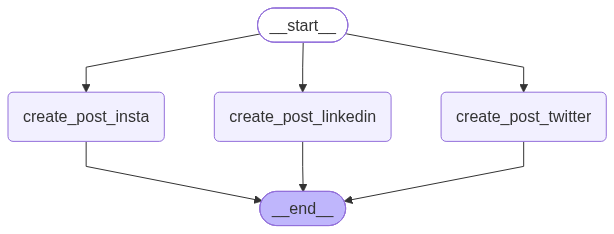

In [8]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("create_post_insta", create_post_insta)
graph.add_node("create_post_twitter", create_post_twitter)
graph.add_node("create_post_linkedin", create_post_linkedin)

graph.add_edge(START, "create_post_insta")
graph.add_edge(START, "create_post_twitter")
graph.add_edge(START, "create_post_linkedin")
graph.add_edge("create_post_insta", END)
graph.add_edge("create_post_twitter", END)
graph.add_edge("create_post_linkedin", END)

parallel_graph = graph.compile()

from IPython.display import Image, display

# You could see the errors with the below command
Image(parallel_graph.get_graph().draw_mermaid_png())

In [9]:
parallel_graph.invoke({"topic": "Artificial Intelligence",
                    "insta": "",
                    "twitter": "",
                    "linkedin": ""})

{'topic': 'Artificial Intelligence',
 'insta': [{'type': 'text',
   'text': 'Robot overlords or the ultimate cheat code? 🤖✨ \n\nLet’s be real, AI went from being sci-fi movie stuff to writing our emails, generating weird pictures of cats in space, and helping us figure out what to cook with random leftovers in the fridge. 🍳🐈\n\nSome days it feels like magic, and other days it’s just saving us 45 minutes of staring at a blank screen. \n\nWhere do you stand? Are you leaning on AI for everything, or are you holding out for the robot apocalypse? Drop your take in the comments! 👇💬\n\n#ArtificialIntelligence #TechTrends #FutureIsNow #AILife #TechHumor',
   'extras': {'signature': 'El4KXAERTTIPoiKhf730ETcEKLBny4AwGn4O/ZW7xYKtPqhq4lqRjG7stfi4uMWwjW611NipiAvR/RWw+8a96n4CHopzcZ93nOA488cGbyrdJZoV6Als69EVjh3Zk7NW'}}],
 'twitter': [{'type': 'text',
   'text': "AI isn't coming for your job. \n\nIt’s coming for the boring parts of your job. \n\nAdapt, automate, and level up. 🚀🤖",
   'extras': {'signa

## **Routers**

In [17]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    
    input: str
    topic: str
    post: str
    category: str

In [18]:
## LLM with Pydantic Schema
from pydantic import BaseModel, Field
from typing import Literal

class llm_schema(BaseModel):
    category: Literal['insta', 'twitter', 'linkedin'] = Field(..., description="Category of the post to generate")
    topic: str = Field(..., description="Topic of the post to generate")

In [19]:
llm_with_schema = llm.with_structured_output(llm_schema)
llm_with_schema.invoke("I want to generate a post for twitter about AI").category

'twitter'

In [33]:
def decider_node(state: graph_schema) -> graph_schema:

    # Extract the input from the state
    user_input = state['input']

    # Passing the user input to the LLM to decide the category of the post to generate
    response = llm_with_schema.invoke(user_input) # Pydantic Object
    category = response.category # Extracting the category from the Pydantic Object
    topic = response.topic # Extracting the topic from the Pydantic Object

    # Update the state with the decided category and topic
    state['category'] = category
    state['topic'] = topic

    return state


def create_post_insta(state: graph_schema) -> graph_schema:

    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate an Instagram post
    post = llm.invoke(f"Write an Instagram post about {topic}. Keep the tone casual and engaging.").content

    # Update the state with the generated post
    state['post'] = post

    return {'post' : post}

def create_post_twitter(state: graph_schema) -> graph_schema:
    

    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate a Twitter post
    post = llm.invoke(f"Write a Twitter post about {topic}. Keep the tone quick").content

    # Update the state with the generated post
    state['post'] = post

    return {'post' : post}


def create_post_linkedin(state: graph_schema) -> graph_schema:
    

    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate a LinkedIn post
    post = llm.invoke(f"Write a LinkedIn post about {topic}. Keep the tone professional and informative.").content

    # Update the state with the generated post
    state['post'] = post

    return {'post' : post}

In [34]:
## condition to trigger based on the category decided by the LLM
def condition(state: graph_schema) -> str:

    category = state['category']

    if category == 'insta':
        return 'create_insta'
    elif category == 'twitter':
        return 'create_twitter'
    elif category == 'linkedin':
        return 'create_linkedin'
    else:
        raise ValueError("Invalid category")

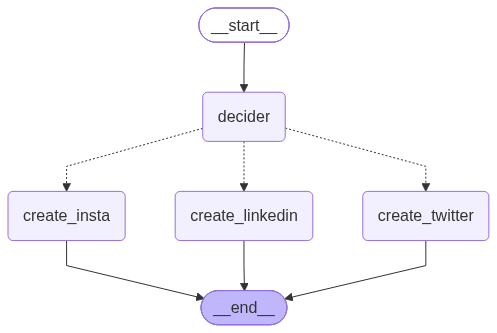

In [35]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("decider", decider_node)
graph.add_node("create_insta", create_post_insta)
graph.add_node("create_twitter", create_post_twitter)
graph.add_node("create_linkedin", create_post_linkedin)


graph.add_edge(START, "decider")
graph.add_conditional_edges("decider",condition,{
    'create_insta': "create_insta",
    'create_twitter': "create_twitter",
    'create_linkedin': "create_linkedin"
})

graph.add_edge("create_insta", END)
graph.add_edge("create_twitter", END)
graph.add_edge("create_linkedin", END) 


route_graph = graph.compile()


from IPython.display import Image, display

# You could see the errors with the below command
Image(route_graph.get_graph().draw_mermaid_png())

In [36]:
route_graph.invoke({
    "input": "I want to generate a post for twitter about AI",
    "topic":"",
    "category":"",
    "post":""
})

{'input': 'I want to generate a post for twitter about AI',
 'topic': 'AI',
 'post': [{'type': 'text',
   'text': 'AI is moving faster than your group chat can keep up. \n\nAre we building the future or just a very smart magic 8-ball? 🤖⚡️',
   'extras': {'signature': 'El4KXAERTTIPABx+uO/w+53sGZLuAdGzMJMu3F57lbBpZyyMsavB0/xtxCytSWh8DUxTbuN03gDrhvanmjX1T44zVmy62OZALRygE/rJIgBzRlnfJGev30q+ogo/tm1s'}}],
 'category': 'twitter'}

## **Query Decomposition**

In [18]:
## Pydantic Schema for Query Decomposition
from pydantic import BaseModel, Field
from typing import List, TypedDict
from langchain_core.prompts import ChatPromptTemplate

class llm_schema(BaseModel):
    tasks: List[str] = Field(..., description="A list of tasks to be performed by the worker.")

llm_with_schema = llm.with_structured_output(llm_schema)

In [19]:
## Graph Schema
class graph_schema(TypedDict):

    tasks: List[str]
    query: str
    results: List[str]
    summary: str

In [35]:
## creating Orchestration Graph for Query Decomposition
def orchestrator_node(state: graph_schema) -> graph_schema:

    # Fetching the user query from the state
    user_query = state['query']

    # Create the prompt for the LLM
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are an orchestrator that breaks down a user query into tasks for the worker."),
            ("user", f"User query: {user_query}. Please generate one prompt per task for the worker to complete. Return the tasks in a list format."),
        ]
    )

    # Create the chain
    chain = prompt | llm_with_schema

    # Run the chain with the user query as input
    response = chain.invoke({"query": user_query})


    # Update the state with the generated tasks
    state['tasks'] = response.tasks

    return state

In [36]:
## Worker Node
def execute(query:str) :

    response = llm.invoke(f"Please execute this task {query}")
    return response.content

In [37]:
from concurrent.futures import ThreadPoolExecutor

def worker_node(state: graph_schema) -> graph_schema:

    tasks = state['tasks']
    results = []

    with ThreadPoolExecutor(max_workers=len(tasks)) as executor:

        results_futures = executor.map(execute, tasks)
        for result in results_futures:
            results.append(result)
    
    state['results'] = results
    
    return state

In [38]:
## Collector Node
def collector_node(state: graph_schema):

    results = state['results']

    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a collector that summarizes the results from the worker."),
            ("user", "Here are the results from the worker: {results}. Please summarize these results in a concise manner."),
        ]
    )


    chain = prompt | llm

    summary = chain.invoke({"results": results})

    state['summary'] = summary.content

    return state

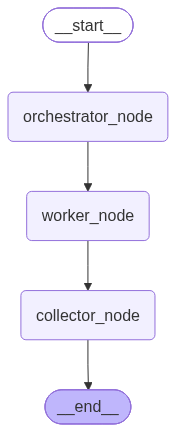

In [39]:
## Creating Graph and Executing it
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("orchestrator_node",orchestrator_node)
graph.add_node("worker_node",worker_node)
graph.add_node("collector_node",collector_node)

graph.add_edge(START, "orchestrator_node")
graph.add_edge("orchestrator_node", "worker_node")
graph.add_edge("worker_node", "collector_node")
graph.add_edge("collector_node", END)

complex_graph = graph.compile()

from IPython.display import Image, display

# You could see the errors with the below command
Image(complex_graph.get_graph().draw_mermaid_png())

In [40]:
for chunk in complex_graph.stream(
    {
        "query": "What is the capital of France and what is the population of Paris? & What is the capital of Germany and what is the population of Berlin?",
        "tasks": [],
        "results": [],
        "summary": "",
    },
    stream_mode="updates"
):
    print(chunk)

{'orchestrator_node': {'tasks': ['What is the capital of France?', 'What is the population of Paris?', 'What is the capital of Germany?', 'What is the population of Berlin?'], 'query': 'What is the capital of France and what is the population of Paris? & What is the capital of Germany and what is the population of Berlin?', 'results': [], 'summary': ''}}
{'worker_node': {'tasks': ['What is the capital of France?', 'What is the population of Paris?', 'What is the capital of Germany?', 'What is the population of Berlin?'], 'query': 'What is the capital of France and what is the population of Paris? & What is the capital of Germany and what is the population of Berlin?', 'results': [[{'type': 'text', 'text': 'The capital of France is **Paris**.', 'extras': {'signature': 'El4KXAERTTIPTBzfc58LwpICi1mWrSN0ieNCnEfAWHvdC4IhbJEMZekN/WlLiZ/pbVh6cuPbVxgdBvaAC4VP2fk/sOjPmFjV6Tkj3P1ci3KFCXMy/462CzHTue3SL5Un'}}], [{'type': 'text', 'text': "As of the most recent data from INSEE (France's national sta

In [41]:
for chunk in complex_graph.stream(
    {
        "query": "What is the capital of France and what is the population of Paris? & What is the capital of Germany and what is the population of Berlin?",
        "tasks": [],
        "results": [],
        "summary": "",
    },
    stream_mode="updates"
):
    print(chunk)

{'orchestrator_node': {'tasks': ['What is the capital of France?', 'What is the population of Paris?', 'What is the capital of Germany?', 'What is the population of Berlin?'], 'query': 'What is the capital of France and what is the population of Paris? & What is the capital of Germany and what is the population of Berlin?', 'results': [], 'summary': ''}}
{'worker_node': {'tasks': ['What is the capital of France?', 'What is the population of Paris?', 'What is the capital of Germany?', 'What is the population of Berlin?'], 'query': 'What is the capital of France and what is the population of Paris? & What is the capital of Germany and what is the population of Berlin?', 'results': [[{'type': 'text', 'text': 'The capital of France is **Paris**.', 'extras': {'signature': 'El4KXAERTTIPqPs+PdFye66SA9w4do7Kn4B36Al8IgD3FW3C1gWwFUb7sEQdMhn7N5AQoGkcu4YzGz5cuPiBH+FFjzhZros5UwjKpSER1X4+bF9wYwHMnAGw3OrahXTC'}}], [{'type': 'text', 'text': 'As of January 2021 data (released by INSEE, the French natio